# 07 — Headline Results (Test Set)


In [1]:
import os, math, json, shutil, time, pickle
from dataclasses import dataclass, field
from collections import defaultdict
from typing import List, Dict, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
torch.manual_seed(42); np.random.seed(42)

import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.4,
    "lines.markersize": 5,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLORS = {
    "softmax":  "#C0392B",
    "sigmoid":  "#27AE60",
    "neutral":  "#2C3E50",
    "grey":     "#7F8C8D",
    "lightgrey":"#BDC3C7",
    "yellow":   "#F39C12",
    "blue":     "#2980B9",
    "purple":   "#8E44AD",
    "keydiff":  "#D35400",
}

def style_for(spec):
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    ls    = "-" if use_rope else "--"
    mk    = "o" if use_rope else "s"
    return color, ls, mk, display

Mounted at /content/drive
Device: cuda


In [2]:
@dataclass
class Config:
    d_model: int = 768
    n_layer: int = 12
    n_head: int = 12
    d_ff: int = 3072
    block_size: int = 512
    vocab_size: int = 50257
    rope_base: float = 10000.0
    use_rope: bool = True
    use_sigmoid: bool = False

cfg_base = Config()

BASE       = "/content/drive/MyDrive/SigEvict"
DATA_DIR   = f"{BASE}/data"
MODEL_DIR  = f"{BASE}/models"
RESULT_DIR = f"{BASE}/results"
FIG_DIR    = f"{BASE}/figures"
TBL_DIR    = f"{BASE}/tables"
for d in [RESULT_DIR, FIG_DIR, TBL_DIR]: os.makedirs(d, exist_ok=True)

MODEL_SPECS = [
    ("gpt2_12L_dense_softmax",              "SM RoPE",         True,    False,   False),
    ("gpt2_12L_softmax_gated",              "SM+G RoPE",       True,    False,   True ),
    ("gpt2_12L_sigmoid_no_gate",            "Sig RoPE",        True,    True,    False),
    ("gpt2_12L_sigmoid_gated",              "Sig+G RoPE",      True,    True,    True ),
    ("gpt2_12L_dense_softmax_norope",       "SM NoPE",         False,   False,   False),
    ("gpt2_12L_softmax_gated_norope",       "SM+G NoPE",       False,   False,   True ),
    ("gpt2_12L_sigmoid_no_gate_norope",     "Sig NoPE",        False,   True,    False),
    ("gpt2_12L_sigmoid_gated_norope",       "Sig+G NoPE",      False,   True,    True ),
]
GATED_SPECS = [s for s in MODEL_SPECS if s[4]]
DENSE_SPECS = [s for s in MODEL_SPECS if not s[4]]
print(f"Registered {len(MODEL_SPECS)} models ({len(GATED_SPECS)} gated, {len(DENSE_SPECS)} dense)")

SMOKE = False

Registered 8 models (4 gated, 4 dense)


## Model definitions (unified across all 8 specs)


In [3]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_len=2048, base=10000.0):
        super().__init__()
        self.register_buffer("inv_freq", 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim)))
    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        return emb.cos(), emb.sin()

def apply_rope(x, cos, sin, offset=0):
    d = x.shape[-1] // 2
    T = x.shape[2]
    x1, x2 = x[..., :d], x[..., d:]
    c = cos[offset:offset+T].unsqueeze(0).unsqueeze(0)
    s = sin[offset:offset+T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1*c[...,:d] - x2*s[...,:d], x1*s[...,:d] + x2*c[...,:d]], dim=-1)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.proj = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)
    def forward(self, x): return self.proj(F.gelu(self.fc(x)))

In [4]:
class SoftmaxAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.masked_fill(self.mask[:T, :T], float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        att = F.softmax(att, dim=-1)
        return self.c_proj((att @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        att = (q @ k.transpose(-2, -1)) * self.scale
        causal = self.mask[start_pos:start_pos+T, :T_full]
        att = att.masked_fill(causal.unsqueeze(0).unsqueeze(0), float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        att = F.softmax(att, dim=-1)
        y = (att @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)

class SigmoidAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())
        self.register_buffer("pos_bias", -torch.log(torch.arange(cfg.block_size, dtype=torch.float32) + 1))

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        logits = (q @ k.transpose(-2, -1)) * self.scale + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        attn = torch.sigmoid(logits.masked_fill(self.mask[:T, :T], -1e9)).masked_fill(self.mask[:T, :T], 0.0)
        return self.c_proj((attn @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        logits = (q @ k.transpose(-2, -1)) * self.scale
        if T == 1:
            logits = logits + (-math.log(start_pos + 1))
        else:
            logits = logits + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        causal = self.mask[start_pos:start_pos+T, :T_full]
        attn = torch.sigmoid(logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9))
        attn = attn.masked_fill(causal.unsqueeze(0).unsqueeze(0), 0.0)
        y = (attn @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)

In [5]:
class Block(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))
    def forward_kv(self, x, kv_cache=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, new_kv

class GatedBlock(nn.Module):
    def __init__(self, cfg, layer_idx, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
        self.has_gate = layer_idx < cfg.n_layer - 1
        if self.has_gate:
            self.gate = nn.Linear(cfg.d_model, 1, bias=True)
    def forward(self, x, kv_mask=None):
        x = x + self.attn(self.ln1(x), kv_mask=kv_mask)
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, g
    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache,
                                                kv_mask=kv_mask, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, new_kv, g

class GPT2Dense(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg, attn_cls) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches = []
        for block in self.blocks:
            x, kv = block.forward_kv(x, kv_cache=None, start_pos=0)
            caches.append(kv)
        logits = self.head(self.ln_f(x))
        return logits, caches

    def decode_step(self, tok, pos, caches):
        x = self.wte(tok)
        new_caches = []
        for l, block in enumerate(self.blocks):
            x, kv = block.forward_kv(x, kv_cache=caches[l], start_pos=pos)
            new_caches.append(kv)
        return self.head(self.ln_f(x)).squeeze(1), new_caches

class GPT2Gated(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([GatedBlock(cfg, i, attn_cls) for i in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        kv_mask, gates = None, []
        for b in self.blocks:
            x, g = b(x, kv_mask=kv_mask)
            if g is not None: gates.append(g)
            kv_mask = g
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        budget = sum(g.mean() for g in gates) / len(gates) if gates else None
        return logits, loss, budget, gates

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches, cache_masks = [], []
        prev_mask = torch.ones(B, T, 1, device=idx.device)
        for block in self.blocks:
            x, kv, gate = block.forward_kv(x, kv_cache=None, kv_mask=prev_mask, start_pos=0)
            caches.append(kv); cache_masks.append(prev_mask)
            prev_mask = gate if gate is not None else torch.ones(B, T, 1, device=idx.device)
        return self.head(self.ln_f(x)), caches, cache_masks

    def decode_step(self, tok, pos, caches, cache_masks):
        B = tok.size(0)
        x = self.wte(tok)
        new_caches, new_cache_masks = [], []
        prev_gate_new = torch.ones(B, 1, 1, device=tok.device)
        for l, block in enumerate(self.blocks):
            kv_mask = torch.cat([cache_masks[l], prev_gate_new], dim=1)
            x, kv, gate = block.forward_kv(x, kv_cache=caches[l], kv_mask=kv_mask, start_pos=pos)
            new_caches.append(kv); new_cache_masks.append(kv_mask)
            prev_gate_new = gate if gate is not None else torch.ones(B, 1, 1, device=tok.device)
        return self.head(self.ln_f(x)).squeeze(1), new_caches, new_cache_masks

def build_model(spec):
    name, display, use_rope, use_sigmoid, gated = spec
    cfg = Config()
    cfg.use_rope = use_rope
    cfg.use_sigmoid = use_sigmoid
    attn_cls = SigmoidAttention if use_sigmoid else SoftmaxAttention
    model = GPT2Gated(cfg, attn_cls) if gated else GPT2Dense(cfg, attn_cls)
    return model, cfg

def load_model(spec, device=device):
    name = spec[0]
    ckpt = torch.load(f"{MODEL_DIR}/{name}.pt", map_location=device, weights_only=False)
    model, cfg = build_model(spec)
    missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if missing or unexpected:
        print(f"  [warn] {name}: missing={len(missing)}, unexpected={len(unexpected)}")
    model = model.to(device).eval()
    best_tau = ckpt.get("best_tau", None)
    return model, cfg, best_tau

In [6]:
def physical_prune(caches, cache_masks, tau):
    """Drop KV entries with gate value < tau (per layer, independent)."""
    new_caches, new_masks = [], []
    for l in range(len(caches)):
        k, v = caches[l]; mask = cache_masks[l]
        keep = (mask.squeeze(-1) >= tau)
        keep_idx = keep[0].nonzero(as_tuple=True)[0]
        if len(keep_idx) == 0:
            keep_idx = torch.tensor([mask.size(1) - 1], device=mask.device)
        new_caches.append((k[:, :, keep_idx, :], v[:, :, keep_idx, :]))
        new_masks.append(mask[:, keep_idx, :])
    return new_caches, new_masks

def prune_new_token(caches, cache_masks, tau):
    new_caches, new_masks = [], []
    for l in range(len(caches)):
        k, v = caches[l]; mask = cache_masks[l]
        if (mask[:, -1:, :] < tau).all():
            new_caches.append((k[:, :, :-1, :], v[:, :, :-1, :]))
            new_masks.append(mask[:, :-1, :])
        else:
            new_caches.append((k, v)); new_masks.append(mask)
    return new_caches, new_masks

@torch.no_grad()
def eval_gated_at_tau(model, tokens, tau, n_seqs, prefill=384, decode=128):
    seq_losses, final_entries = [], []
    for si in range(n_seqs):
        s = si * (prefill + decode)
        if s + prefill + decode > len(tokens): break
        toks = tokens[s:s+prefill+decode].unsqueeze(0).to(device)
        prefix, suffix = toks[:, :prefill], toks[:, prefill:]
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            pf_logits, caches, cmasks = model.prefill(prefix)
            if tau > 0:
                caches, cmasks = physical_prune(caches, cmasks, tau)
            seq = [F.cross_entropy(pf_logits[:, -1, :], suffix[:, 0]).item()]
            for t in range(decode - 1):
                logits, caches, cmasks = model.decode_step(
                    suffix[:, t:t+1], prefill + t, caches, cmasks)
                if tau > 0:
                    caches, cmasks = prune_new_token(caches, cmasks, tau)
                seq.append(F.cross_entropy(logits, suffix[:, t+1]).item())
        seq_losses.append(sum(seq) / len(seq))
        final_entries.append(sum(c[0].size(2) for c in caches))
    return seq_losses, sum(final_entries) / len(final_entries)

@torch.no_grad()
def eval_dense_protocol(model, tokens, n_seqs, prefill=384, decode=128):
    """Dense PPL on suffix tokens via single forward pass; matches gated protocol."""
    seq_losses = []
    for si in range(n_seqs):
        s = si * (prefill + decode)
        if s + prefill + decode > len(tokens): break
        toks = tokens[s:s+prefill+decode].unsqueeze(0).to(device)
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            logits, _ = model(toks)
        lg = logits[:, prefill-1:prefill+decode-1, :].reshape(-1, logits.size(-1))
        tg = toks[:, prefill:prefill+decode].reshape(-1)
        per_tok = F.cross_entropy(lg, tg, reduction="none")
        seq_losses.append(per_tok.mean().item())
    return seq_losses

## Load test tokens and best_tau


In [7]:
LOCAL = "/content/local_data"; os.makedirs(LOCAL, exist_ok=True)
src, dst = f"{DATA_DIR}/owt_test_1M.pt", f"{LOCAL}/owt_test_1M.pt"
if not os.path.exists(dst):
    print("Copying test tokens to local SSD...")
    shutil.copy(src, dst)
test_tokens = torch.load(dst, weights_only=True)
print(f"Test tokens: {len(test_tokens):,}")

with open(f"{RESULT_DIR}/best_taus.json") as f:
    best_taus_meta = json.load(f)
best_taus = best_taus_meta["best_taus"]
print(f"Loaded best_taus: {best_taus}")

PREFILL, DECODE = 384, 128
N_TEST = 20 if SMOKE else (len(test_tokens) - 1) // (PREFILL + DECODE)
print(f"N_TEST = {N_TEST}  ({N_TEST * DECODE:,} scored decode tokens)")

Copying test tokens to local SSD...
Test tokens: 1,000,000
Loaded best_taus: {'gpt2_12L_softmax_gated': 0.01, 'gpt2_12L_sigmoid_gated': 0.05, 'gpt2_12L_softmax_gated_norope': 0.01, 'gpt2_12L_sigmoid_gated_norope': 0.05}
N_TEST = 1953  (249,984 scored decode tokens)


## Table 1 — Full test PPL on all 8 models (no eviction)


In [8]:
class TokenDataset(Dataset):
    def __init__(self, tokens, block_size):
        self.tokens, self.block_size = tokens, block_size
    def __len__(self): return (len(self.tokens) - 1) // self.block_size
    def __getitem__(self, i):
        s = i * self.block_size
        return self.tokens[s:s+self.block_size], self.tokens[s+1:s+self.block_size+1]

_test = test_tokens[:512*200] if SMOKE else test_tokens
test_loader = DataLoader(TokenDataset(_test, cfg_base.block_size),
                         batch_size=32, drop_last=True, num_workers=2, pin_memory=True)

@torch.no_grad()
def evaluate_full(model):
    total, n = 0.0, 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            out = model(x, y)
        total += out[1].item(); n += 1
    avg = total / n
    return {"loss": avg, "ppl": math.exp(min(avg, 20.0))}

test_results = {}
for spec in MODEL_SPECS:
    name, display = spec[0], spec[1]
    print(f"Evaluating {display}...")
    model, _, btau = load_model(spec)
    r = evaluate_full(model)
    r["best_tau"] = btau
    r["n_params"] = sum(p.numel() for p in model.parameters())
    test_results[name] = r
    print(f"  Loss={r['loss']:.4f}  PPL={r['ppl']:.3f}  best_τ={btau}  params={r['n_params']:,}")
    del model; torch.cuda.empty_cache()

Evaluating SM RoPE...
  Loss=3.1801  PPL=24.049  best_τ=None  params=123,571,968
Evaluating SM+G RoPE...
  Loss=3.1926  PPL=24.352  best_τ=0.01  params=123,580,427
Evaluating Sig RoPE...
  Loss=3.1938  PPL=24.380  best_τ=None  params=123,571,968
Evaluating Sig+G RoPE...
  Loss=3.1928  PPL=24.356  best_τ=0.05  params=123,580,427
Evaluating SM NoPE...
  Loss=3.2402  PPL=25.538  best_τ=None  params=123,571,968
Evaluating SM+G NoPE...
  Loss=3.2426  PPL=25.600  best_τ=0.01  params=123,580,427
Evaluating Sig NoPE...
  Loss=3.2835  PPL=26.668  best_τ=None  params=123,571,968
Evaluating Sig+G NoPE...
  Loss=3.2840  PPL=26.683  best_τ=0.05  params=123,580,427


## Post-hoc eviction policies (H2O + KeyDiff)


In [9]:
@torch.no_grad()
def prefill_with_attn(model, cfg, idx, pos_shift=False):
    B, T = idx.shape
    x = model.wte(idx)
    C = x.shape[-1]
    caches, attns = [], []
    for block in model.blocks:
        am = block.attn
        h = block.ln1(x)
        q, k, v = am.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        k = k.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        v = v.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        q, k = am.q_norm(q), am.k_norm(k)

        if cfg.use_rope:
            cos, sin = am.rotary(T, x.device)
            q_rope = apply_rope(q, cos, sin)
            k_rope = apply_rope(k, cos, sin)
            cache_k = k if pos_shift else k_rope
        else:
            q_rope, k_rope = q, k
            cache_k = k

        if hasattr(am, "pos_bias"):
            logits = (q_rope @ k_rope.transpose(-2, -1)) * am.scale + am.pos_bias[:T].view(1, 1, T, 1)
            logits = logits.masked_fill(am.mask[:T, :T], -1e9)
            att = torch.sigmoid(logits).masked_fill(am.mask[:T, :T], 0.0)
        else:
            logits = (q_rope @ k_rope.transpose(-2, -1)) * am.scale
            logits = logits.masked_fill(am.mask[:T, :T], float("-inf"))
            att = F.softmax(logits, dim=-1)
        attns.append(att.detach().float())
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        x = x + am.c_proj(y)
        x = x + block.mlp(block.ln2(x))
        caches.append((cache_k, v))
    logits = model.head(model.ln_f(x))
    return logits, caches, attns

@torch.no_grad()
def decode_step_with_attn(model, cfg, tok, pos, caches, pos_shift=False):
    B, T = tok.shape
    assert T == 1
    x = model.wte(tok)
    C = x.shape[-1]
    new_caches, attns = [], []
    for l, block in enumerate(model.blocks):
        am = block.attn
        h = block.ln1(x)
        q, k_new, v_new = am.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        k_new = k_new.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        v_new = v_new.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        q, k_new = am.q_norm(q), am.k_norm(k_new)

        if cfg.use_rope:
            if pos_shift:
                k_all_raw = torch.cat([caches[l][0], k_new], dim=2) if caches is not None else k_new
                L = k_all_raw.size(2)
                cos, sin = am.rotary(L, x.device)
                q_rope = apply_rope(q, cos, sin, offset=L - 1)
                k_for_attn = apply_rope(k_all_raw, cos, sin, offset=0)
                cache_k_after = k_all_raw
            else:
                cos, sin = am.rotary(pos + T, x.device)
                q_rope = apply_rope(q, cos, sin, offset=pos)
                k_new_rope = apply_rope(k_new, cos, sin, offset=pos)
                k_for_attn = torch.cat([caches[l][0], k_new_rope], dim=2) if caches is not None else k_new_rope
                cache_k_after = k_for_attn
        else:
            q_rope = q
            k_for_attn = torch.cat([caches[l][0], k_new], dim=2) if caches is not None else k_new
            cache_k_after = k_for_attn

        v = torch.cat([caches[l][1], v_new], dim=2) if caches is not None else v_new
        T_full = k_for_attn.size(2)

        if hasattr(am, "pos_bias"):
            logits = (q_rope @ k_for_attn.transpose(-2, -1)) * am.scale - math.log(pos + 1)
            if pos_shift:
                att = torch.sigmoid(logits)
            else:
                causal = am.mask[pos:pos+T, :T_full]
                logits = logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9)
                att = torch.sigmoid(logits).masked_fill(causal.unsqueeze(0).unsqueeze(0), 0.0)
        else:
            logits = (q_rope @ k_for_attn.transpose(-2, -1)) * am.scale
            if not pos_shift:
                causal = am.mask[pos:pos+T, :T_full]
                logits = logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), float("-inf"))
            att = F.softmax(logits, dim=-1)
        attns.append(att.detach().float())
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        x = x + am.c_proj(y)
        x = x + block.mlp(block.ln2(x))
        new_caches.append((cache_k_after, v))
    logits = model.head(model.ln_f(x)).squeeze(1)
    return logits, new_caches, attns

def _gather_kv(kv, idx):
    k, v = kv
    return k[:, :, idx, :], v[:, :, idx, :]

def _gather_kv_headwise(kv, idx):
    k, v = kv
    B, H, _, D = k.shape
    if idx.dim() == 1:
        return _gather_kv(kv, idx)
    idx = idx.to(k.device)
    idx_exp = idx.unsqueeze(0).unsqueeze(-1).expand(B, H, idx.size(-1), D)
    return k.gather(2, idx_exp), v.gather(2, idx_exp)

class NoEviction:
    pos_shift = False
    def __init__(self, target_keep=None, seq_seed=0): pass
    def after_prefill(self, caches, attns): return caches
    def after_decode(self, caches, attns): return caches

class H2OKVCacheLayerWise:
    def __init__(self, hh_size=4, recent_size=512):
        self.hh_size = int(hh_size)
        self.recent_size = int(recent_size)
        self.cache_size = self.hh_size + self.recent_size
        self.hh_score = None
    def _update_hh_score(self, attn_score_cache):
        num_new_tokens = attn_score_cache.shape[2]
        scores = attn_score_cache.sum(0).sum(1)
        if self.hh_score is None:
            self.hh_score = scores
        else:
            scores[:, :-num_new_tokens] += self.hh_score
            self.hh_score = scores
    def __call__(self, kv, attn_score_cache):
        self._update_hh_score(attn_score_cache)
        k, v = kv
        seq_len = k.size(2)
        if seq_len <= self.cache_size:
            return kv
        B, H, _, D = k.shape
        keep_parts = []
        if self.hh_size > 0:
            select_scores = self.hh_score[:, :seq_len - self.recent_size]
            keep_topk = torch.topk(select_scores, self.hh_size, dim=-1).indices.sort().values
            keep_parts.append(keep_topk)
        if self.recent_size > 0:
            keep_recent = torch.arange(seq_len - self.recent_size, seq_len, device=k.device).repeat(H, 1)
            keep_parts.append(keep_recent)
        keep_idx = torch.cat(keep_parts, dim=-1)
        mask = torch.zeros((H, seq_len), dtype=torch.bool, device=k.device).scatter(-1, keep_idx, True)
        k_new = k[0][mask].view(H, self.cache_size, D).unsqueeze(0)
        v_new = v[0][mask].view(H, self.cache_size, D).unsqueeze(0)
        self.hh_score = self.hh_score[mask].view(H, self.cache_size)
        return k_new, v_new

class H2OPolicy:
    pos_shift = False
    def __init__(self, target_keep, seq_seed=0, recent_ratio=0.5):
        keep   = max(1, int(target_keep))
        recent = min(keep, max(1, int(keep * recent_ratio)))
        heavy  = keep - recent
        self.layers = None
        self.hh_size = heavy
        self.recent_size = recent
    def _ensure_layers(self, n_layers):
        if self.layers is None:
            self.layers = [H2OKVCacheLayerWise(self.hh_size, self.recent_size) for _ in range(n_layers)]
    def after_prefill(self, caches, attns):
        self._ensure_layers(len(caches))
        return [m(kv, att) for m, kv, att in zip(self.layers, caches, attns)]
    def after_decode(self, caches, attns):
        self._ensure_layers(len(caches))
        return [m(kv, att) for m, kv, att in zip(self.layers, caches, attns)]


class KeyDiffKVCacheLayerWise:
    """KeyDiff-style real KV dropping with the evaluated raw-key anchor variant.

    KeyDiff is a training-free, attention-score-free key-geometry policy.
    For each head, it computes an anchor as the mean of the raw keys, scores
    cached entries by cosine similarity to that anchor, and retains the keys
    with the LOWEST similarity, i.e. the most geometrically distinctive keys.

    This implements the paper-described efficient/raw-key-anchor variant rather
    than the normalized-key derivation variant. It assumes B=1, matching the
    per-sequence PPL evaluation path used in this notebook.
    """
    def __init__(self, cache_size):
        self.cache_size = max(1, int(cache_size))

    def __call__(self, kv, attn_score_cache=None):
        k, v = kv
        seq_len = k.size(2)
        if seq_len <= self.cache_size:
            return kv

        # Per-head KeyDiff selection. k: [B=1, H, T, D].
        B, H, T, D = k.shape
        assert B == 1, "This evaluation path assumes batch size 1."

        k_float = k[0].float()                       # [H, T, D]
        anchor = k_float.mean(dim=1, keepdim=True)   # raw-key anchor μ(K), [H, 1, D]
        cosine_to_anchor = F.cosine_similarity(
            k_float,
            anchor.expand_as(k_float),
            dim=-1,
        )                                            # [H, T]

        # KeyDiff keeps the lowest anchor similarities.
        keep_idx = torch.topk(
            cosine_to_anchor,
            k=self.cache_size,
            dim=-1,
            largest=False,
            sorted=False,
        ).indices.sort(dim=-1).values
        return _gather_kv_headwise(kv, keep_idx)

class KeyDiffPolicy:
    pos_shift = False
    def __init__(self, target_keep, seq_seed=0):
        self.cache_size = max(1, int(target_keep))
        self.layers = None
    def _ensure_layers(self, n_layers):
        if self.layers is None:
            self.layers = [KeyDiffKVCacheLayerWise(self.cache_size) for _ in range(n_layers)]
    def after_prefill(self, caches, attns):
        self._ensure_layers(len(caches))
        return [m(kv) for m, kv in zip(self.layers, caches)]
    def after_decode(self, caches, attns):
        self._ensure_layers(len(caches))
        return [m(kv) for m, kv in zip(self.layers, caches)]

POLICY_FACTORIES = {
    "H2O":     lambda target_keep, seq_seed=0: H2OPolicy(
        target_keep, seq_seed=seq_seed, recent_ratio=0.5),
    "KeyDiff": lambda target_keep, seq_seed=0: KeyDiffPolicy(
        target_keep, seq_seed=seq_seed),
}
POLICY_NAMES = ["H2O", "KeyDiff"]

def get_policy(name):
    return POLICY_FACTORIES[name]

POLICIES = [(n, get_policy(n)) for n in POLICY_NAMES]
NoEvictionPolicy = NoEviction

@torch.no_grad()
def decode_dense(model, cfg, caches, suffix, pf_logits, policy, start_pos=None):
    if start_pos is None:
        start_pos = PREFILL
    pos_shift = getattr(policy, "pos_shift", False)
    losses = [F.cross_entropy(pf_logits[:, -1, :], suffix[:, 0]).item()]
    for t in range(suffix.size(1) - 1):
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            logits, caches, attns = decode_step_with_attn(
                model, cfg, suffix[:, t:t+1], start_pos + t, caches, pos_shift=pos_shift)
            caches = policy.after_decode(caches, attns)
        losses.append(F.cross_entropy(logits, suffix[:, t+1]).item())
    return sum(losses)/len(losses), sum(c[0].size(2) for c in caches)

@torch.no_grad()
def eval_posthoc(model, cfg, policy_factory, target_keep, n_seqs):
    seq_losses, final_entries = [], []
    for si in range(n_seqs):
        s = si * (PREFILL + DECODE)
        if s + PREFILL + DECODE > len(test_tokens): break
        toks = test_tokens[s:s+PREFILL+DECODE].unsqueeze(0).to(device)
        prefix, suffix = toks[:, :PREFILL], toks[:, PREFILL:]
        policy = policy_factory(target_keep, seq_seed=si)
        pos_shift = getattr(policy, "pos_shift", False)
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            pf_logits, caches, attns = prefill_with_attn(model, cfg, prefix, pos_shift=pos_shift)
            caches = policy.after_prefill(caches, attns)
            loss, ent = decode_dense(model, cfg, caches, suffix, pf_logits, policy)
        seq_losses.append(loss); final_entries.append(ent)
    return seq_losses, sum(final_entries)/len(final_entries)

## Run no-eviction references on the 4 dense backbones


In [10]:
posthoc_ref_per_backbone = {}

for spec in DENSE_SPECS:
    name, display = spec[0], spec[1]
    print(f"\n=== Dense backbone: {display} ===")
    model, cfg, _ = load_model(spec)

    print(">> No eviction (reference; dense reference for post-hoc backbone eval)")
    losses, entries = eval_posthoc(model, cfg, lambda target_keep, seq_seed=0: NoEvictionPolicy(target_keep, seq_seed=seq_seed),
                                   target_keep=PREFILL, n_seqs=N_TEST)
    ppl = math.exp(min(np.mean(losses), 20.0))
    posthoc_ref_per_backbone[name] = {
        "display": display, "ppl": ppl,
        "entries": entries, "losses": losses,
    }
    print(f"   PPL={ppl:.3f}  entries/layer={entries/cfg.n_layer:.1f}")

    del model; torch.cuda.empty_cache()


=== Dense backbone: SM RoPE ===
>> No eviction (reference; dense reference for post-hoc backbone eval)
   PPL=22.079  entries/layer=511.0

=== Dense backbone: Sig RoPE ===
>> No eviction (reference; dense reference for post-hoc backbone eval)
   PPL=22.440  entries/layer=511.0

=== Dense backbone: SM NoPE ===
>> No eviction (reference; dense reference for post-hoc backbone eval)
   PPL=23.398  entries/layer=511.0

=== Dense backbone: Sig NoPE ===
>> No eviction (reference; dense reference for post-hoc backbone eval)
   PPL=24.603  entries/layer=511.0


## Run learned-gate operating points (4 gated models @ best_tau)


In [ ]:
learned_results = {}
for spec in GATED_SPECS:
    name, display = spec[0], spec[1]
    btau = best_taus.get(name)
    if btau is None:
        print(f"  [skip] {display}: no best_tau"); continue
    print(f">> {display}  τ={btau:.3f}")
    model, cfg, _ = load_model(spec)
    losses, ent = eval_gated_at_tau(model, test_tokens, btau, N_TEST,
                                    prefill=PREFILL, decode=DECODE)
    ppl = math.exp(min(np.mean(losses), 20.0))
    ref_name = name.replace("_softmax_gated", "_dense_softmax").replace(
        "_sigmoid_gated", "_sigmoid_no_gate")
    if ref_name in posthoc_ref_per_backbone:
        ref_ent = posthoc_ref_per_backbone[ref_name]["entries"]
    else:
        ref_ent = ent / 0.5
    actual_comp = (1 - ent / ref_ent) * 100
    learned_results[name] = {"display": display, "tau": btau,
                             "compression": actual_comp,
                             "entries": ent, "ppl": ppl, "losses": losses}
    print(f"   compression={actual_comp:5.1f}%  PPL={ppl:.3f}")
    del model; torch.cuda.empty_cache()

>> SM+G RoPE  τ=0.010
   compression= 19.2%  PPL=22.514
>> Sig+G RoPE  τ=0.050
   compression= 19.8%  PPL=22.424
>> SM+G NoPE  τ=0.010
   compression= 10.2%  PPL=23.576
>> Sig+G NoPE  τ=0.050
   compression= 32.2%  PPL=24.637


## Sigmoid+Gate vs Softmax+Gate at validation-selected operating points


In [ ]:
print("=" * 70)
print("DIRECT COMPARISONS at val-selected operating points (full test set)")
print("=" * 70)

for pe in ["RoPE", "NoPE"]:
    sm_name = f"gpt2_12L_softmax_gated{'_norope' if pe=='NoPE' else ''}"
    sg_name = f"gpt2_12L_sigmoid_gated{'_norope' if pe=='NoPE' else ''}"
    if sm_name not in learned_results or sg_name not in learned_results:
        continue
    sm_ppl = learned_results[sm_name]["ppl"]
    sg_ppl = learned_results[sg_name]["ppl"]
    delta = sg_ppl - sm_ppl
    print(f"\n{pe}: Sig+G PPL − SM+G PPL = {delta:+.3f}")
    print(f"  SM+G:  {sm_ppl:.3f}  comp={learned_results[sm_name]['compression']:.1f}%  "
          f"τ={learned_results[sm_name]['tau']:.3f}")
    print(f"  Sig+G: {sg_ppl:.3f}  comp={learned_results[sg_name]['compression']:.1f}%  "
          f"τ={learned_results[sg_name]['tau']:.3f}")

print("\n" + "=" * 70)
print("LEARNED GATE @ best_tau VS DENSE NO-EVICTION (same backbone family)")
print("=" * 70)
for gs in GATED_SPECS:
    gn = gs[0]
    if gn not in learned_results: continue
    use_rope, use_sig = gs[2], gs[3]
    dn = next(s[0] for s in DENSE_SPECS if s[2]==use_rope and s[3]==use_sig)
    if dn not in posthoc_ref_per_backbone: continue
    ref_ppl = posthoc_ref_per_backbone[dn]["ppl"]
    g_ppl   = learned_results[gn]["ppl"]
    delta   = g_ppl - ref_ppl
    pe_str  = "norope" if not use_rope else "rope"
    print(f"\n{gs[1]} @ τ={learned_results[gn]['tau']:.3f} "
          f"(comp={learned_results[gn]['compression']:.1f}%) vs {pe_str} dense:")
    print(f"  ΔPPL = {delta:+.3f}  (learned PPL {g_ppl:.3f} − dense PPL {ref_ppl:.3f})")

DIRECT COMPARISONS at val-selected operating points (full test set)

RoPE: Sig+G PPL − SM+G PPL = -0.090
  SM+G:  22.514  comp=19.2%  τ=0.010
  Sig+G: 22.424  comp=19.8%  τ=0.050

NoPE: Sig+G PPL − SM+G PPL = +1.061
  SM+G:  23.576  comp=10.2%  τ=0.010
  Sig+G: 24.637  comp=32.2%  τ=0.050

LEARNED GATE @ best_tau VS DENSE NO-EVICTION (same backbone family)

SM+G RoPE @ τ=0.010 (comp=19.2%) vs rope dense:
  ΔPPL = +0.435  (learned PPL 22.514 − dense PPL 22.079)

Sig+G RoPE @ τ=0.050 (comp=19.8%) vs rope dense:
  ΔPPL = -0.016  (learned PPL 22.424 − dense PPL 22.440)

SM+G NoPE @ τ=0.010 (comp=10.2%) vs norope dense:
  ΔPPL = +0.178  (learned PPL 23.576 − dense PPL 23.398)

Sig+G NoPE @ τ=0.050 (comp=32.2%) vs norope dense:
  ΔPPL = +0.035  (learned PPL 24.637 − dense PPL 24.603)


## Matched-compression comparison on the 4 dense backbones


In [ ]:
matched_results = {}

FULL_FINAL = PREFILL + DECODE - 1
COMPRESSION_TOL = 1.0
MAX_COMPRESSION_BY_POLICY = {
    "H2O": (1 - 1 / FULL_FINAL) * 100,
    "KeyDiff": (1 - 1 / FULL_FINAL) * 100,
}

def paired_gated_name_for_spec(spec):
    """Return the learned-gated model name with the same attention and PE."""
    _, _, use_rope, use_sigmoid, _ = spec
    return next(
        gs[0] for gs in GATED_SPECS
        if gs[2] == use_rope and gs[3] == use_sigmoid
    )

def paired_dense_name_for_gated_spec(gspec):
    """Return the dense backbone name with the same attention and PE."""
    _, _, use_rope, use_sigmoid, _ = gspec
    return next(
        ds[0] for ds in DENSE_SPECS
        if ds[2] == use_rope and ds[3] == use_sigmoid
    )

print(f"Decode bookkeeping: PREFILL={PREFILL}, DECODE={DECODE}  =>  FULL_FINAL={FULL_FINAL}")
print("Policy modes: H2O/KeyDiff maintain an online cache budget after prefill and after each decode step.")
print("StreamingLLM is intentionally removed from the main comparison.")
print("Post-hoc baselines are run only on the 4 dense backbones, then compared to the paired learned-gate model.")

for bb in DENSE_SPECS:
    bb_name, bb_disp = bb[0], bb[1]
    target_gated = paired_gated_name_for_spec(bb)
    if target_gated not in learned_results:
        print(f"[skip] {bb_disp}: no learned target for {target_gated}")
        continue
    if bb_name not in posthoc_ref_per_backbone:
        print(f"[skip] {bb_disp}: no no-eviction reference")
        continue

    target_comp_pct = learned_results[target_gated]["compression"]
    target_comp = target_comp_pct / 100.0
    desired_final_keep = max(1, int(round((1 - target_comp) * FULL_FINAL)))

    ref_ent = posthoc_ref_per_backbone[bb_name]["entries"]
    learned_mean_loss = float(np.mean(learned_results[target_gated]["losses"]))
    learned_ppl = math.exp(min(learned_mean_loss, 20.0))

    print(f"\n>>> Dense backbone {bb_disp}  matched to {learned_results[target_gated]['display']} "
          f"target_comp={target_comp_pct:.1f}%  online_budget/layer={desired_final_keep}")

    model, cfg, _ = load_model(bb)
    matched_results[bb_name] = {
        "target_gated": target_gated,
        "target_gated_display": learned_results[target_gated]["display"],
        "target_compression": target_comp_pct,
        "desired_final_keep_per_layer": desired_final_keep,
        "backbone": bb_name,
        "backbone_display": bb_disp,
        "backbone_is_gated_checkpoint": False,
        "learned_ppl": learned_results[target_gated]["ppl"],
        "learned_compression": learned_results[target_gated]["compression"],
        "policy_scope": "online-only baselines on dense backbone: H2O and KeyDiff",
    }

    for pname in POLICY_NAMES:
        policy_target_keep = desired_final_keep
        pfn = get_policy(pname)
        losses_p, ent_p = eval_posthoc(model, cfg, pfn, policy_target_keep, N_TEST)
        ppl_p = math.exp(min(np.mean(losses_p), 20.0))
        actual = (1 - ent_p / ref_ent) * 100
        gap = abs(actual - target_comp_pct)
        delta = ppl_p - learned_ppl
        warn = "  [WARN gap>1pp]" if gap > COMPRESSION_TOL else ""

        matched_results[bb_name][pname] = {
            "ppl": ppl_p,
            "compression": actual,
            "compression_gap": gap,
            "entries": ent_p,
            "policy_target_keep": policy_target_keep,
            "policy_mode": "online-budget",
            "feasible": True,
            "max_policy_compression": float(MAX_COMPRESSION_BY_POLICY[pname]),
            "delta_vs_learned": delta,
            "losses": losses_p,
        }
        print(f"   {pname:<10}  online-budget  keep={policy_target_keep:<4d} "
              f"comp={actual:5.1f}% (gap {gap:.2f}pp)  "
              f"PPL={ppl_p:.3f}  Δ(post-hoc − learned target)={delta:+.3f}{warn}")

    del model
    torch.cuda.empty_cache()


Decode bookkeeping: PREFILL=384, DECODE=128  =>  FULL_FINAL=511
Policy modes: H2O/KeyDiff maintain an online cache budget after prefill and after each decode step.
StreamingLLM is intentionally removed from the main comparison.
Post-hoc baselines are run only on the 4 dense backbones, then compared to the paired learned-gate model.

>>> Dense backbone SM RoPE  matched to SM+G RoPE target_comp=19.2%  online_budget/layer=413
   H2O         online-budget  keep=413  comp= 19.2% (gap 0.05pp)  PPL=22.145  Δ(post-hoc − learned target)=-0.369
   KeyDiff     online-budget  keep=413  comp= 19.2% (gap 0.05pp)  PPL=22.984  Δ(post-hoc − learned target)=+0.469

>>> Dense backbone Sig RoPE  matched to Sig+G RoPE target_comp=19.8%  online_budget/layer=410
   H2O         online-budget  keep=410  comp= 19.8% (gap 0.02pp)  PPL=22.480  Δ(post-hoc − learned target)=+0.056
   KeyDiff     online-budget  keep=410  comp= 19.8% (gap 0.02pp)  PPL=22.474  Δ(post-hoc − learned target)=+0.050

>>> Dense backbone SM

## Fig 1 — Matched-compression: post-hoc baselines vs learned gates


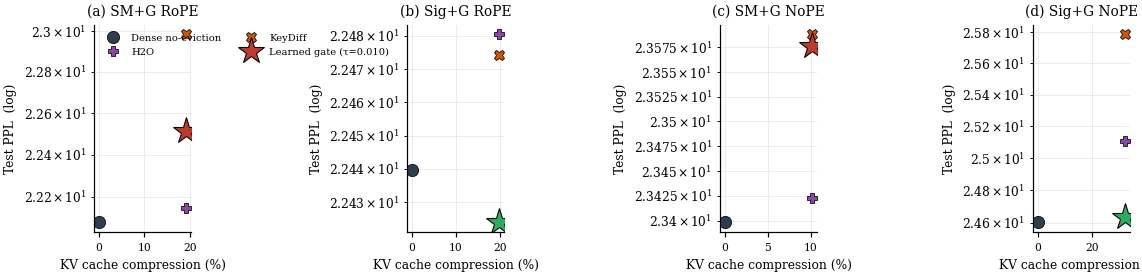

Saved /content/drive/MyDrive/SigEvict/figures/fig1_pareto_headline.{pdf,png}


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(10.5, 2.7), sharey=False)

method_marker = {"H2O": "P", "KeyDiff": "X"}
method_color  = {"H2O": COLORS["purple"], "KeyDiff": COLORS["keydiff"]}

for k, gs in enumerate(GATED_SPECS):
    ax = axes[k]
    gn = gs[0]
    if gn not in learned_results:
        ax.axis("off")
        continue
    dense_name = paired_dense_name_for_gated_spec(gs)
    if dense_name not in matched_results or dense_name not in posthoc_ref_per_backbone:
        ax.axis("off")
        continue

    g = learned_results[gn]
    ref = posthoc_ref_per_backbone[dense_name]
    ax.plot([0], [ref["ppl"]], color=COLORS["neutral"], marker="o", ms=8, ls="None",
            label="Dense no-eviction", mec="black", mew=0.5)

    for pname in POLICY_NAMES:
        m = matched_results[dense_name][pname]
        if not m.get("feasible", True):
            continue
        ax.plot([m["compression"]], [m["ppl"]],
                color=method_color[pname], marker=method_marker[pname],
                ms=7, ls="None", label=pname, mec="black", mew=0.5)

    color_star = COLORS["sigmoid"] if "sigmoid" in gn else COLORS["softmax"]
    ax.plot([g["compression"]], [g["ppl"]],
            color=color_star, marker="*", ms=18, ls="None",
            label=f"Learned gate (τ={g['tau']:.3f})",
            mec="black", mew=0.7)

    ax.set_yscale("log")
    ax.set_xlabel("KV cache compression (%)", fontsize=8)
    ax.set_ylabel("Test PPL  (log)", fontsize=8)
    ax.set_title(f"({chr(ord('a')+k)}) {g['display']}", fontsize=9)
    ax.grid(alpha=0.3, which="both", lw=0.5)
    ax.tick_params(labelsize=7)
    if k == 0:
        ax.legend(fontsize=6.5, loc="upper left", ncol=2)

plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/fig1_pareto_headline.{ext}", dpi=300)
plt.show()
print(f"Saved {FIG_DIR}/fig1_pareto_headline.{{pdf,png}}")


## Fig 3 — 2×2×2 factorial grid (operating-point view)


/tmp/ipykernel_600/3243959416.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plot_grid(axes[0,0], ppl_rope, "(a) PPL @ operating point — RoPE", "{:.2f}", cm.get_cmap("RdYlGn_r"))
/tmp/ipykernel_600/3243959416.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plot_grid(axes[1,0], ppl_nope, "(d) PPL @ operating point — NoPE", "{:.2f}", cm.get_cmap("RdYlGn_r"))
/tmp/ipykernel_600/3243959416.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plot_grid(axe

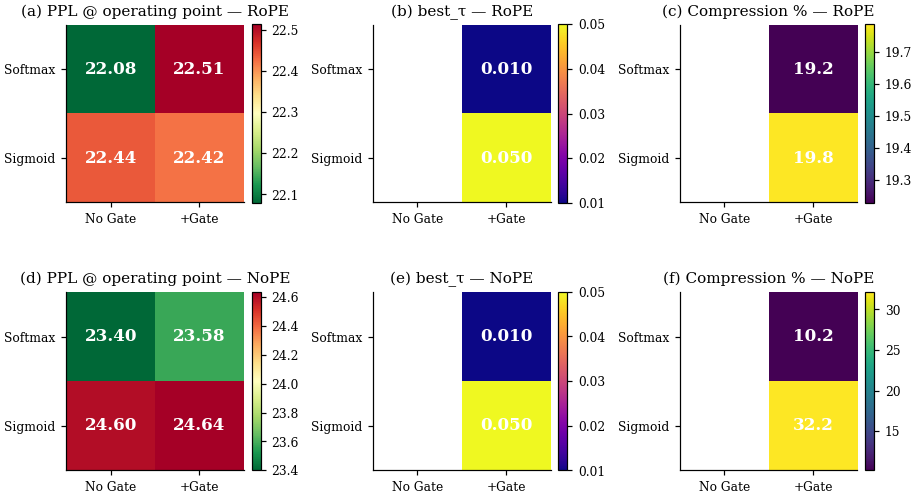

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(8.5, 5.0))

def plot_grid(ax, grid, title, fmt, cmap):
    im = ax.imshow(grid, cmap=cmap, aspect="equal")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No Gate", "+Gate"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Softmax", "Sigmoid"])
    ax.set_title(title, fontsize=10)
    for i in range(2):
        for j in range(2):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if cmap.name in ("RdYlGn_r","viridis","plasma") else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def operating_ppl(spec):
    name = spec[0]
    if spec[4]:
        return learned_results[name]["ppl"] if name in learned_results else np.nan
    return posthoc_ref_per_backbone[name]["ppl"] if name in posthoc_ref_per_backbone else np.nan

ppl_rope = np.full((2,2), np.nan)
for spec in MODEL_SPECS:
    if not spec[2]: continue
    i = 1 if spec[3] else 0; j = 1 if spec[4] else 0
    ppl_rope[i,j] = operating_ppl(spec)

ppl_nope = np.full((2,2), np.nan)
for spec in MODEL_SPECS:
    if spec[2]: continue
    i = 1 if spec[3] else 0; j = 1 if spec[4] else 0
    ppl_nope[i,j] = operating_ppl(spec)

import matplotlib.cm as cm
plot_grid(axes[0,0], ppl_rope, "(a) PPL @ operating point — RoPE", "{:.2f}", cm.get_cmap("RdYlGn_r"))
plot_grid(axes[1,0], ppl_nope, "(d) PPL @ operating point — NoPE", "{:.2f}", cm.get_cmap("RdYlGn_r"))

btau_rope = np.full((2,2), np.nan)
btau_nope = np.full((2,2), np.nan)
for spec in GATED_SPECS:
    if spec[0] not in best_taus: continue
    i = 1 if spec[3] else 0; j = 1
    if spec[2]: btau_rope[i,j] = best_taus[spec[0]]
    else:       btau_nope[i,j] = best_taus[spec[0]]
plot_grid(axes[0,1], btau_rope, "(b) best_τ — RoPE", "{:.3f}", cm.get_cmap("plasma"))
plot_grid(axes[1,1], btau_nope, "(e) best_τ — NoPE", "{:.3f}", cm.get_cmap("plasma"))

comp_rope = np.full((2,2), np.nan)
comp_nope = np.full((2,2), np.nan)
for spec in GATED_SPECS:
    if spec[0] not in learned_results: continue
    i = 1 if spec[3] else 0; j = 1
    c = learned_results[spec[0]]["compression"]
    if spec[2]: comp_rope[i,j] = c
    else:       comp_nope[i,j] = c
plot_grid(axes[0,2], comp_rope, "(c) Compression % — RoPE", "{:.1f}", cm.get_cmap("viridis"))
plot_grid(axes[1,2], comp_nope, "(f) Compression % — NoPE", "{:.1f}", cm.get_cmap("viridis"))

plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/fig3_factorial_grid.{ext}", dpi=300)
plt.show()

## Sup. Fig — paired per-sequence comparison (Sigmoid+G vs Softmax+G, RoPE)


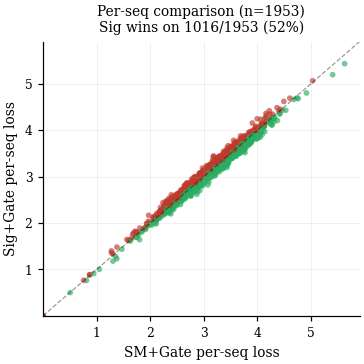

In [ ]:
sm_name = "gpt2_12L_softmax_gated"
sg_name = "gpt2_12L_sigmoid_gated"
if sm_name in learned_results and sg_name in learned_results:
    a = np.array(learned_results[sm_name]["losses"])
    b = np.array(learned_results[sg_name]["losses"])
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    lim = (min(a.min(), b.min())*0.95, max(a.max(), b.max())*1.05)
    ax.plot(lim, lim, "k--", alpha=0.4, lw=0.8)
    win_b = (b < a).sum()
    sc = ax.scatter(a, b, s=14, c=[COLORS["sigmoid"] if bi < ai else COLORS["softmax"] for ai, bi in zip(a, b)],
                    alpha=0.65, edgecolors="none")
    ax.set_xlabel("SM+Gate per-seq loss")
    ax.set_ylabel("Sig+Gate per-seq loss")
    ax.set_title(f"Per-seq comparison (n={len(a)})\nSig wins on {win_b}/{len(a)} ({win_b/len(a)*100:.0f}%)",
                 fontsize=9)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.grid(alpha=0.3, lw=0.4)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(f"{FIG_DIR}/sup_paired_scatter.{ext}", dpi=300)
    plt.show()

## Tables (LaTeX): dense backbones + learned gates + H2O/KeyDiff


In [ ]:
def fmt_pct(x): return f"{x:.1f}\\%"
ROW_END = r"\\"

print("=" * 100)
print("Table 1 — Dense no-eviction references")
print("=" * 100)
lines = [
    r"\begin{tabular}{lcccc}",
    r"\toprule",
    f"Backbone & Attention & Position & PPL & Params {ROW_END}",
    r"\midrule",
]
for spec in DENSE_SPECS:
    name = spec[0]
    if name not in test_results:
        continue
    r = test_results[name]
    attn = "Sigmoid" if spec[3] else "Softmax"
    pe   = "RoPE" if spec[2] else "NoPE"
    lines.append(f"{spec[1]} & {attn} & {pe} & {r['ppl']:.2f} & {r['n_params']:,} {ROW_END}")
lines += [r"\bottomrule", r"\end{tabular}"]
with open(f"{TBL_DIR}/table1_dense_test_ppl.tex", "w") as f:
    f.write("\n".join(lines))
print("\n".join(lines))

print()
print("=" * 100)
print("Table 2 — Learned-gate operating points")
print("=" * 100)
lines2 = [
    r"\begin{tabular}{lccc}",
    r"\toprule",
    f"Gated model & $\\tau^\\star$ & Comp.\\ (\\%) & PPL {ROW_END}",
    r"\midrule",
]
for gs in GATED_SPECS:
    gn = gs[0]
    if gn not in learned_results:
        continue
    lr = learned_results[gn]
    lines2.append(f"{gs[1]} & {lr['tau']:.3f} & {lr['compression']:.1f} & {lr['ppl']:.3f} {ROW_END}")
lines2 += [r"\bottomrule", r"\end{tabular}"]
with open(f"{TBL_DIR}/table2_learned_operating_points.tex", "w") as f:
    f.write("\n".join(lines2))
print("\n".join(lines2))

print()
print("=" * 100)
print("Table 3 — Matched-compression post-hoc baselines on the 4 dense backbones")
print("=" * 100)
lines3 = [
    r"\begin{tabular}{llcccc}",
    r"\toprule",
    f"Dense backbone & Learned target & Budget/layer & H$_2$O PPL & KeyDiff PPL & Comp.\\ (\\%) {ROW_END}",
    r"\midrule",
]
for spec in DENSE_SPECS:
    bb_name, bb_disp = spec[0], spec[1]
    if bb_name not in matched_results:
        continue
    mr = matched_results[bb_name]
    h2o = mr["H2O"]
    kd  = mr["KeyDiff"]
    comp_mean = 0.5 * (h2o["compression"] + kd["compression"])
    lines3.append(
        f"{bb_disp} & {mr['target_gated_display']} & {mr['desired_final_keep_per_layer']} & "
        f"{h2o['ppl']:.3f} & {kd['ppl']:.3f} & {comp_mean:.1f} {ROW_END}"
    )
lines3 += [r"\bottomrule", r"\end{tabular}"]
with open(f"{TBL_DIR}/table3_posthoc_4_dense_backbones.tex", "w") as f:
    f.write("\n".join(lines3))
print("\n".join(lines3))

print()
print("=" * 100)
print("Table 4 — Main comparison: learned gates vs H2O/KeyDiff on paired dense backbones")
print("=" * 100)
lines4 = [
    r"\begin{tabular}{lccccc}",
    r"\toprule",
    f"Model & $\\tau^\\star$ & Comp.\\ (\\%) & Learned PPL & H$_2$O & KeyDiff {ROW_END}",
    r"\midrule",
]
for gs in GATED_SPECS:
    gn = gs[0]
    if gn not in learned_results:
        continue
    dense_name = paired_dense_name_for_gated_spec(gs)
    if dense_name not in matched_results:
        continue
    lr = learned_results[gn]
    mr = matched_results[dense_name]
    lines4.append(
        f"{gs[1]} & {lr['tau']:.3f} & {lr['compression']:.1f} & "
        f"{lr['ppl']:.3f} & {mr['H2O']['ppl']:.3f} & {mr['KeyDiff']['ppl']:.3f} {ROW_END}"
    )
lines4 += [r"\bottomrule", r"\end{tabular}"]
with open(f"{TBL_DIR}/table4_headline_h2o_keydiff_4_backbones.tex", "w") as f:
    f.write("\n".join(lines4))
print("\n".join(lines4))


Table 1 — Dense no-eviction references
\begin{tabular}{lcccc}
\toprule
Backbone & Attention & Position & PPL & Params \\
\midrule
SM RoPE & Softmax & RoPE & 24.05 & 123,571,968 \\
Sig RoPE & Sigmoid & RoPE & 24.38 & 123,571,968 \\
SM NoPE & Softmax & NoPE & 25.54 & 123,571,968 \\
Sig NoPE & Sigmoid & NoPE & 26.67 & 123,571,968 \\
\bottomrule
\end{tabular}

Table 2 — Learned-gate operating points
\begin{tabular}{lccc}
\toprule
Gated model & $\tau^\star$ & Comp.\ (\%) & PPL \\
\midrule
SM+G RoPE & 0.010 & 19.2 & 22.514 \\
Sig+G RoPE & 0.050 & 19.8 & 22.424 \\
SM+G NoPE & 0.010 & 10.2 & 23.576 \\
Sig+G NoPE & 0.050 & 32.2 & 24.637 \\
\bottomrule
\end{tabular}

Table 3 — Matched-compression post-hoc baselines on the 4 dense backbones
\begin{tabular}{llcccc}
\toprule
Dense backbone & Learned target & Budget/layer & H$_2$O PPL & KeyDiff PPL & Comp.\ (\%) \\
\midrule
SM RoPE & SM+G RoPE & 413 & 22.145 & 22.984 & 19.2 \\
Sig RoPE & Sig+G RoPE & 410 & 22.480 & 22.474 & 19.8 \\
SM NoPE & SM+G No

## Persist all numbers


In [ ]:
def _strip(rows):
    return [{k: v for k, v in r.items() if k != "losses"} for r in rows]

summary = {
    "test_results": test_results,
    "learned_results": {n: {k: (v if k != "losses" else None) for k, v in r.items()}
                        for n, r in learned_results.items()},
    "posthoc_ref": {n: {k: (v if k != "losses" else None) for k, v in r.items()}
                    for n, r in posthoc_ref_per_backbone.items()},
    "matched_results": {
        gn: {k: (v if k != "losses" else None) if not isinstance(v, dict)
             else {kk: (vv if kk != "losses" else None) for kk, vv in v.items()}
             for k, v in r.items()}
        for gn, r in matched_results.items()
    },
    "config": {
        "prefill": PREFILL, "decode": DECODE, "n_test": N_TEST,
        "policy_modes": {
            "H2O": "online heavy+recent budget",
            "KeyDiff": "online key-similarity diversity budget",
        },
        "posthoc_backbones": "4 dense backbones only; compared to paired learned-gate targets",
        "h2o": {
            "variant": "layerwise real-drop H2O-style eviction",
            "budget_split": "50% heavy hitter / 50% recent",
            "batch_size": 1,
        },
        "keydiff": {
            "variant": "raw-key-anchor KeyDiff-style eviction",
            "anchor": "mean of raw keys μ(K)",
            "selection": "retain lowest cosine similarity to raw-key anchor",
            "attention_scores": "not used",
            "batch_size": 1,
        },
        "split": "test", "best_taus": best_taus,
    },
}
with open(f"{RESULT_DIR}/test_results.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print(f"Saved {RESULT_DIR}/test_results.json")

Saved /content/drive/MyDrive/SigEvict/results/test_results.json
